# Taller 1 — Notebook 01: Entendimiento inicial de datos

**MINE-4101: Ciencia de Datos Aplicada · Supervisión de contratación pública de bienes**

**Integrantes:** Daniel Triviño · Nicolás Bedoya

---

## Objetivo del notebook

Este notebook cubre el **Entregable 1 (20%)**: entendimiento inicial del dataset de contratos de
bienes de SECOP II (2019–2025). Aquí:

1. Reportamos **dimensiones** y **tipos de datos**.
2. Seleccionamos el **top-5 de atributos** más relevantes para el análisis y describimos su
   comportamiento (**análisis univariado**).
3. Establecemos y **justificamos el periodo** apropiado para el análisis.
4. Documentamos los **problemas de calidad de datos** detectados y cómo decidimos tratarlos.

> **Orden de ejecución del proyecto:** `01_entendimiento` → `02_limpieza` → `03_analisis`.
> Este notebook es exploratorio y **no modifica** el dataset; las correcciones se aplican en `02_limpieza`.


In [1]:
# --- Configuración e imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_DATOS = '../data/raw/secop_bienes.parquet'
RUTA_FIGS = '../figs'


In [2]:
# --- Carga de datos ---
df = pd.read_parquet(RUTA_DATOS)
print(f'Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)


Dimensiones del dataset: 196,391 filas x 36 columnas


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,"17,897,916.00",17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,"390,000,000.00",389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,"11,970,000.00",11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 1. Dimensiones y tipos de datos

El dataset contiene contratos de bienes (compraventa y suministros) firmados por entidades públicas
colombianas entre 2019 y 2025. Revisamos la estructura general.


In [3]:
# Resumen de columnas: tipo, no-nulos y % de nulos
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'no_nulos': df.notna().sum(),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(),
})
resumen.sort_values('pct_nulos', ascending=False)


,tipo,no_nulos,nulos,pct_nulos,n_unicos
fecha_de_inicio_del_contrato,datetime64[us],193951,2440,1.24,2796
id_contrato,object,196391,0,0.00,196391
departamento,object,196391,0,0.00,34
nombre_entidad,object,196391,0,0.00,3452
ciudad,object,196391,0,0.00,676
orden,object,196391,0,0.00,4
rama,object,196391,0,0.00,5
sector,object,196391,0,0.00,26
tipo_de_contrato,object,196391,0,0.00,2
modalidad_de_contratacion,object,196391,0,0.00,9


In [4]:
# Conteo de columnas por tipo de dato
tipos = df.dtypes.astype(str).value_counts()
print('Columnas por tipo de dato:')
print(tipos.to_string())
print()
# Clasificación funcional de variables
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
fechas = df.select_dtypes(include=['datetime']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Numéricas ({len(numericas)}): {numericas}')
print(f'Fechas ({len(fechas)}): {fechas}')
print(f'Texto/categóricas ({len(categoricas)}): {len(categoricas)} columnas')


Columnas por tipo de dato:
object            28
int64              4
datetime64[us]     3
float64            1

Numéricas (5): ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago', 'dias_adicionados']
Fechas (3): ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']
Texto/categóricas (28): 28 columnas


**Observaciones de tipos:**

- La mayoría de columnas son de **texto** (categóricas o identificadores/URLs).
- Hay 3 columnas de **fecha** (`fecha_de_firma`, `fecha_de_inicio_del_contrato`, `fecha_de_fin_del_contrato`).
- Las **numéricas** son los valores monetarios (`valor_del_contrato`, `valor_pagado`, `valor_facturado`,
  `valor_pendiente_de_pago`) y `dias_adicionados`.
- `duraci_n_del_contrato` viene como **texto** ("245 Dia(s)", "5 Mes(es)", "No definido") — deberá parsearse
  en la etapa de limpieza.
- Los nulos son bajos: el máximo es `fecha_de_inicio_del_contrato` (~1,2%).


## 2. Top-5 de atributos y análisis univariado

El enunciado nos da una pista de por dónde mirar: valor, modalidad, sector, tipo de entidad y destino del gasto.
Con ese criterio de negocio —qué características, conocidas al firmar, podrían anticipar un problema— elegimos
estos 5 atributos para el análisis univariado (la justificación es *a priori*; más adelante, en `03`, veremos
cuáles terminan pesando más):

| # | Atributo | Por qué lo elegimos |
|---|----------|---------------------|
| 1 | `valor_del_contrato` | Es la magnitud del riesgo en plata; el enunciado lo pone primero |
| 2 | `sector` | Distintos sectores compran cosas muy distintas y con procesos distintos |
| 3 | `modalidad_de_contratacion` | Define cuánta competencia y control tuvo el proceso |
| 4 | `tipo_de_contrato` | Comprar de una vez (compraventa) no es lo mismo que ir surtiendo (suministro) |
| 5 | `dias_adicionados` | Es, literalmente, una de las desviaciones que queremos entender |

Este top-5 es el foco del univariado de este entregable; el análisis de `03` usa además `orden`, `destino_gasto`,
`liquidaci_n`, `valor_facturado` y `estado_contrato`. El rol de cada variable está en el **inventario (2.6)**, y
`estado_contrato` lo vemos en la sección 3, que es donde nos ayuda a decidir el periodo.


### 2.1 `valor_del_contrato` (numérica)

In [5]:
vc = df['valor_del_contrato']
print('Estadísticos de valor_del_contrato (COP):')
print(vc.describe([.01, .05, .25, .5, .75, .95, .99]).to_string())
print()
print(f'Contratos con valor <= 0: {(vc <= 0).sum():,}')
print(f'Máximo: {vc.max():,.0f}  (valor implausible -> outlier de calidad)')
print(f'Mediana: {vc.median():,.0f}   Media: {vc.mean():,.0f}  (media >> mediana: fuerte sesgo a la derecha)')


Estadísticos de valor_del_contrato (COP):
count                  196,391.00
mean            65,824,255,027.86
std         29,015,352,967,838.23
min                          0.00
1%                     701,068.00
5%                   2,309,772.50
25%                 12,021,214.00
50%                 33,600,000.00
75%                100,000,000.00
95%                800,000,000.00
99%              4,118,481,942.98
max     12,858,450,316,000,000.00

Contratos con valor <= 0: 188
Máximo: 12,858,450,316,000,000  (valor implausible -> outlier de calidad)
Mediana: 33,600,000   Media: 65,824,255,028  (media >> mediana: fuerte sesgo a la derecha)


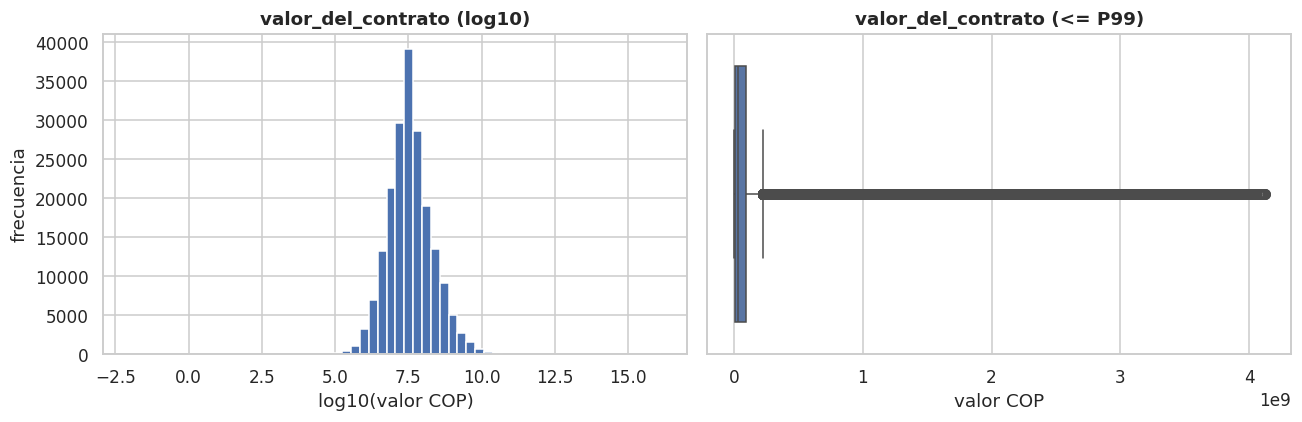

In [6]:
# Distribución en escala log (por el fuerte sesgo). Se excluyen valores <= 0 solo para graficar.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pos = vc[vc > 0]
axes[0].hist(np.log10(pos), bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('valor_del_contrato (log10)')
axes[0].set_xlabel('log10(valor COP)'); axes[0].set_ylabel('frecuencia')

# Boxplot recortado al percentil 99 para ver la caja
p99 = pos.quantile(0.99)
sns.boxplot(x=pos[pos <= p99], ax=axes[1], color='#4C72B0')
axes[1].set_title('valor_del_contrato (<= P99)')
axes[1].set_xlabel('valor COP')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_valor_contrato.png', bbox_inches='tight'); plt.show()


El valor de los contratos está **muy desbalanceado hacia arriba**: la mitad de los contratos vale menos de
~33,6 millones, pero el promedio se dispara a ~66 mil millones porque unos pocos son gigantescos (y hay un máximo
imposible de ~1,3e16 COP, claramente un error). Dos consecuencias prácticas: para analizarlo conviene usar
**escala logarítmica**, y hay que **tratar los valores extremos** en la limpieza.


### 2.2 `sector` (categórica)

26 sectores distintos. Más frecuentes y menos frecuentes:
sector
Servicio Público                    37390
defensa                             34585
No aplica/No pertenece              24465
Salud y Protección Social           22037
Ley de Justicia                     20377
Trabajo                             14759
Educación Nacional                  10231
Ambiente y Desarrollo Sostenible     8109
   ...
sector
Información Estadística                          470
Relaciones Exteriores                            332
Inteligencia Estratégica y Contrainteligencia    100
No Definido                                        9


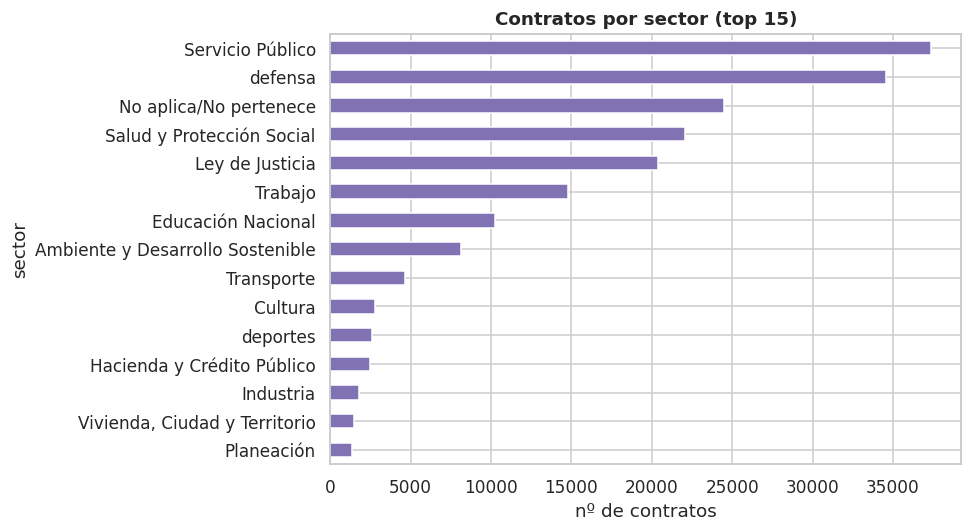

In [7]:
sec = df['sector'].value_counts()
print(f'{df["sector"].nunique()} sectores distintos. Más frecuentes y menos frecuentes:')
print(sec.head(8).to_string()); print('   ...'); print(sec.tail(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
sec.head(15).sort_values().plot(kind='barh', ax=ax, color='#8172B3')
ax.set_title('Contratos por sector (top 15)'); ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_sector.png', bbox_inches='tight'); plt.show()


Hay **26 sectores** distintos y la contratación se concentra en unos pocos. Como cada sector compra cosas
distintas y con dinámicas distintas, esperamos que sea una variable útil para el análisis (lo confirmaremos en
`03`). *(Un detalle de calidad: algunas etiquetas vienen en minúscula —p. ej. `defensa`—; lo tratamos en la
sección 4 y lo estandarizamos en `02`.)*


### 2.3 `modalidad_de_contratacion` (categórica)

modalidad_de_contratacion
Mínima cuantía                                                 117753
Selección abreviada subasta inversa                             32907
Contratación régimen especial                                   19250
Selección Abreviada de Menor Cuantía                             8822
Contratación régimen especial (con ofertas)                      6154
Contratación Directa (con ofertas)                               5001
Contratación directa                                             3938
Licitación pública                                               2330
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       236

Modalidad dominante: Mínima cuantía (60.0% de los contratos)


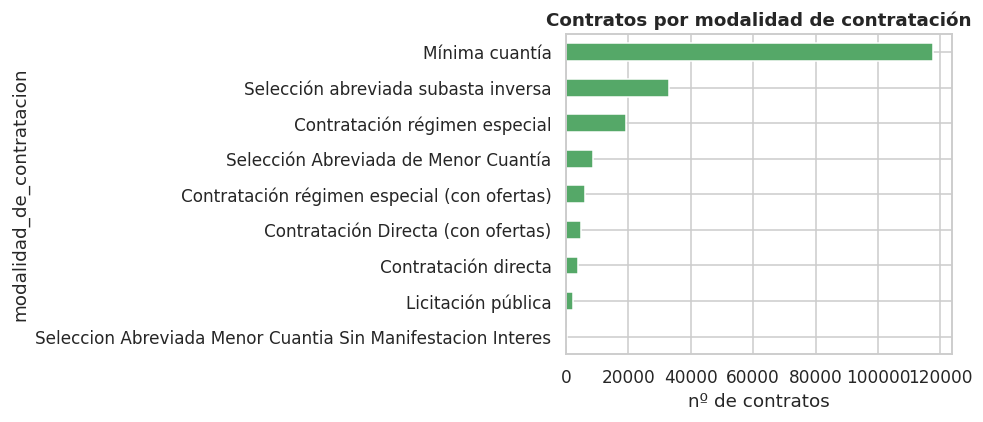

In [8]:
mod = df['modalidad_de_contratacion'].value_counts()
print(mod.to_string())
print(f'\nModalidad dominante: {mod.index[0]} ({mod.iloc[0]/len(df)*100:.1f}% de los contratos)')

fig, ax = plt.subplots(figsize=(9, 4))
mod.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Contratos por modalidad de contratación')
ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_modalidad.png', bbox_inches='tight'); plt.show()


La gran mayoría de los contratos (~60%) se hace por **mínima cuantía**, y le sigue la **subasta inversa**.
O sea, la compra de bienes se apoya sobre todo en modalidades de montos chicos —lo cual cuadra con que la mitad
de los contratos valga poco.


### 2.4 `tipo_de_contrato` (categórica)

tipo_de_contrato
Suministros    106632
Compraventa     89759

Reparto: Suministros 54.3%  |  Compraventa 45.7%


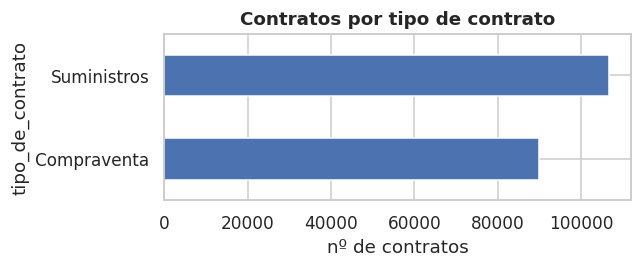

In [9]:
tc = df['tipo_de_contrato'].value_counts()
print(tc.to_string())
print(f'\nReparto: {tc.index[0]} {tc.iloc[0]/len(df)*100:.1f}%  |  {tc.index[1]} {tc.iloc[1]/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 2.6))
tc.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Contratos por tipo de contrato'); ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_tipo_contrato.png', bbox_inches='tight'); plt.show()


Solo hay dos tipos, bastante parejos: **Suministros** (~54%) y **Compraventa** (~46%). La distinción
importa porque son formas distintas de comprar —de una sola vez vs. ir surtiendo—, y esperamos que se comporten
distinto frente a las desviaciones (lo veremos en `03`).


### 2.5 `dias_adicionados` (numérica — una de las desviaciones)

Estadísticos de dias_adicionados:
count   196,391.00
mean          5.11
std          40.66
min           0.00
50%           0.00
90%           0.00
95%          30.00
99%         122.00
max      14,276.00

Contratos con adición de plazo (>0): 18,671  (9.5%)
Máximo: 14,276 días (~39 años -> outlier implausible)


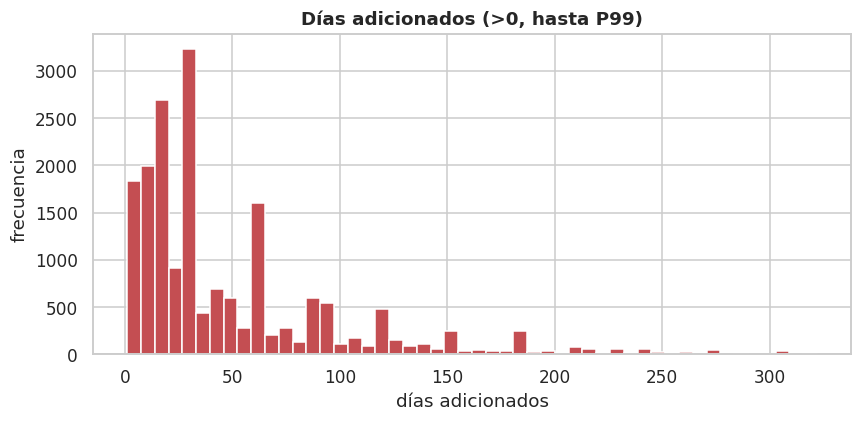

In [10]:
da = df['dias_adicionados']
print('Estadísticos de dias_adicionados:')
print(da.describe([.9, .95, .99]).to_string())
print()
print(f'Contratos con adición de plazo (>0): {(da > 0).sum():,}  ({(da > 0).mean()*100:.1f}%)')
print(f'Máximo: {da.max():,} días (~{da.max()/365:.0f} años -> outlier implausible)')

fig, ax = plt.subplots(figsize=(8, 4))
adic = da[(da > 0) & (da <= da[da > 0].quantile(0.99))]
ax.hist(adic, bins=50, color='#C44E52', edgecolor='white')
ax.set_title('Días adicionados (>0, hasta P99)')
ax.set_xlabel('días adicionados'); ax.set_ylabel('frecuencia')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_dias_adicionados.png', bbox_inches='tight'); plt.show()


Casi todos los contratos (~90%) **no** piden plazo extra: la variable está pegada al cero, con una cola
larga hacia la derecha. Ese ~9,5% que sí pide adición es justo la señal que nos interesa. El máximo (~14.276
días, casi 40 años) es un error y lo trataremos como outlier.


### 2.6 Inventario de variables usadas en el ejercicio

Para dar trazabilidad completa, este es el rol de cada variable a lo largo del ejercicio (limpieza, construcción
de banderas, análisis). El **top-5** anterior es el foco del univariado; el análisis usa además las siguientes:

| Variable | Rol en el ejercicio |
|----------|---------------------|
| `valor_del_contrato` | **Top-5** · predictor (3 desviaciones) · limpieza de outliers |
| `sector` | **Top-5** · predictor H4 (no-liquidación) · estandarización de casing |
| `modalidad_de_contratacion` | **Top-5** · predictor H2 (adición) |
| `tipo_de_contrato` | **Top-5** · predictor H3 (subejecución) |
| `dias_adicionados` | **Top-5** · define bandera `adicion_plazo` · tratamiento de outliers |
| `orden` | Predictor H4 (no-liquidación) |
| `destino_gasto` | Predictor secundario (H3/adición); segmentación Funcionamiento/Inversión |
| `es_pyme` | Predictor H5 (hipótesis nula) |
| `estado_contrato` | Filtro `ciclo_cerrado`; decisión de periodo (sección 3) |
| `liquidaci_n` | Define bandera `sin_liquidar` |
| `valor_facturado` | Define bandera `subejecucion` (ratio de ejecución) |
| `valor_pagado`, `valor_pendiente_de_pago` | Diagnóstico de calidad/consistencia (subreporte, identidad) |
| `fecha_de_firma` / `_inicio` / `_fin` | `anio_firma`, periodo, chequeos de consistencia temporal |
| `duraci_n_del_contrato` | Parseo a `duracion_dias` |
| `id_contrato` | Identificador (verificación de unicidad) |

**No se usan** (14 columnas): identificadores/URLs y texto libre (`nombre_entidad`, `objeto_del_contrato`,
`urlproceso`, `proveedor_adjudicado`, `documento_proveedor`, `codigo_de_categoria_principal`,
`condiciones_de_entrega`), atributos del representante legal (`g_nero_representante_legal`,
`nacionalidad_representante_legal`) y geografía/otros (`departamento`, `ciudad`, `rama`, `entidad_centralizada`,
`origen_de_los_recursos`). Se excluyen por ser identificadores, texto no estructurado o dimensiones fuera del
alcance de focalización de este análisis; podrían explorarse en trabajo futuro (p. ej. geografía).


## 3. Decisión del periodo de análisis (justificada)

El rango cubre 7 años y el enunciado advierte que **no todos son comparables**. La variable `estado_contrato`
—que define qué contratos tienen ciclo completable— es la clave de esta decisión, así que la analizamos aquí.


estado_contrato
terminado       54230
En ejecución    51441
Cerrado         46824
Modificado      34462
Aprobado         9211
Suspendido        153
cedido             43
Cancelado          26
Borrador            1


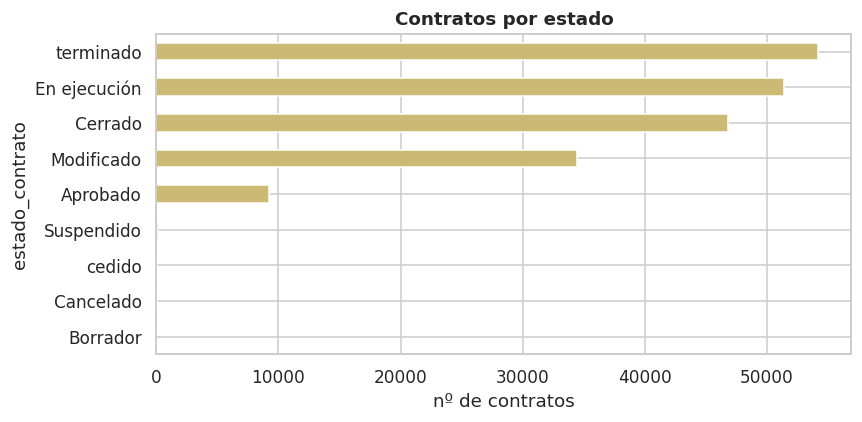

In [11]:
ec = df['estado_contrato'].value_counts()
print(ec.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ec.sort_values().plot(kind='barh', ax=ax, color='#CCB974')
ax.set_title('Contratos por estado')
ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_estado_contrato.png', bbox_inches='tight'); plt.show()


Los estados se reparten entre **terminado / En ejecución / Cerrado / Modificado**, con ~51k contratos aún
**En ejecución**. Esto es determinante: un contrato en ejecución todavía no ha ejecutado todo su presupuesto ni
se ha liquidado, así que **no es comparable** con uno cerrado para medir subejecución o no-liquidación.
Verificamos a continuación con datos cómo el año de firma y el estado condicionan la medición de las desviaciones.


In [12]:
# % de valor_pagado == 0 y % en ejecución, por año de firma
df_p = df.copy()
df_p['anio_firma'] = df_p['fecha_de_firma'].dt.year
tabla = df_p.groupby('anio_firma').agg(
    contratos=('id_contrato', 'size'),
    pct_pagado_cero=('valor_pagado', lambda s: (s == 0).mean() * 100),
    pct_en_ejecucion=('estado_contrato', lambda s: (s == 'En ejecución').mean() * 100),
    pct_terminado_cerrado=('estado_contrato', lambda s: s.isin(['terminado', 'Cerrado']).mean() * 100),
).round(1)
tabla


,contratos,pct_pagado_cero,pct_en_ejecucion,pct_terminado_cerrado
anio_firma,,,,
2019,16425,72.10,0.00,52.80
2020,20135,64.00,19.00,57.10
2021,24043,59.10,24.90,58.70
2022,28070,52.80,25.40,59.00
2023,32971,52.70,29.00,53.00
2024,34634,47.10,28.60,52.70
2025,40113,50.30,37.50,36.00


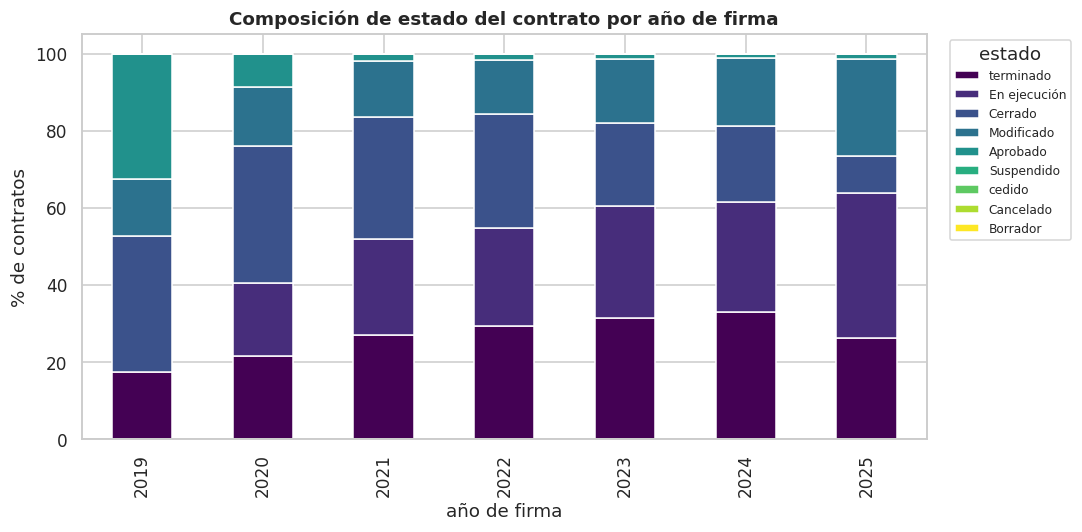

In [13]:
# Visual: estado del contrato por año de firma (proporción)
ct = pd.crosstab(df_p['anio_firma'], df_p['estado_contrato'], normalize='index') * 100
orden_estados = df['estado_contrato'].value_counts().index
ct = ct[[c for c in orden_estados if c in ct.columns]]
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Composición de estado del contrato por año de firma')
ax.set_ylabel('% de contratos'); ax.set_xlabel('año de firma')
ax.legend(title='estado', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_estado_por_anio.png', bbox_inches='tight'); plt.show()


### Qué periodo usamos (y por qué)

La tabla nos dice dos cosas:

- **Los contratos recientes todavía están "en veremos".** El % en ejecución sube con el año (de 0% en 2019 a
  ~37,5% en 2025) y el % ya cerrado cae en 2025 (~36%). Es decir, muchos de 2024–2025 siguen abiertos: si los
  metiéramos como si estuvieran terminados, parecería que "se desviaron" contratos que en realidad solo están en
  curso. Eso dañaría las medidas de subejecución y de no-liquidación.
- **Ojo con `valor_pagado`: viene muy incompleto.** El % de contratos con pagado en cero es alto en *todos* los
  años (52%–72%), y hasta mayor en los años viejos. Eso no es efecto del periodo, sino que el campo está
  **subreportado** en la fuente. Por eso en `03` no medimos la subejecución solo con `valor_pagado`: usamos
  también `valor_facturado` y nos quedamos con contratos ya cerrados.

**Lo que decidimos:** para las desviaciones que necesitan que el contrato haya cerrado (subejecución y
no-liquidación), nos quedamos con contratos de **ciclo ya mayormente cerrado** —en la práctica, **firmas hasta
2023**— y fijamos el corte exacto en `02`. Las **adiciones de plazo** sí se pueden ver antes de que cierre, así
que ahí podemos usar una ventana un poco más amplia. Lo del `valor_pagado` incompleto queda anotado como una
limitación de medición.


## 4. Calidad de datos

Son datos administrativos reales, así que antes de analizarlos hay que preguntarse **qué tan confiables son**.
Para no hacerlo a ojo, se analiza usando las dimensiones y niveles del curso:

- **Dimensiones** — *qué* se afecta: completitud, consistencia, conformidad, relevancia, precisión,
  procesabilidad, disponibilidad, temporalidad y credibilidad.
- **Niveles** — *dónde* aparece el problema: en un **atributo** (un valor suelto), en un **registro** (un contrato
  cuyos campos no cuadran entre sí), en una **columna**, en la **tabla** o entre **múltiples tablas**.

Recorremos los niveles de abajo hacia arriba, mirando las columnas que usa el análisis (inventario 2.6). Cada
hallazgo queda **registrado** con su nivel, su dimensión, cuántos contratos afecta y el tratamiento que le damos
en `02_limpieza`; al final, el catálogo (4.7) se arma solo a partir de esos registros, así ninguna cifra se escribe
a mano. Este notebook no modifica los datos.

In [14]:
hallazgos = []

def registrar(nivel, dimension, columna, problema, n, tratamiento):
    """Anota un hallazgo de calidad para el catálogo de la sección 4.7."""
    hallazgos.append(dict(nivel=nivel, dimension=dimension, columna=columna, problema=problema,
                          n=int(n), pct=round(n / len(df) * 100, 2), tratamiento=tratamiento))
    print(f'[{nivel} · {dimension}] {columna}: {problema} -> {int(n):,} ({n / len(df) * 100:.2f}%)')

### 4.1 Nivel de atributo: ¿cada valor, por sí solo, está bien?

A este nivel hay cuatro tipos de problema: **valores faltantes**, **violaciones de sintaxis**, **errores de
digitación** y **violaciones de dominio**.

#### Valores faltantes → *completitud*

Nulos explícitos casi no hay (solo `fecha_de_inicio_del_contrato`). Pero un dato también puede faltar
**disfrazado**: textos como "No Definido" o "No aplica" que ocupan el lugar de la categoría, o ceros que no
significan "cero pesos" sino "no se reportó".

In [15]:
registrar('atributo', 'completitud', 'fecha_de_inicio_del_contrato', 'nulo',
          df['fecha_de_inicio_del_contrato'].isna().sum(), 'Imputar con fecha_de_firma y marcar la imputación')

for col in ['sector', 'orden', 'destino_gasto']:
    disfrazado = df[col].str.lower().str.startswith(('no definido', 'no aplica'))
    registrar('atributo', 'completitud', col, 'faltante disfrazado ("No Definido" / "No aplica")',
              disfrazado.sum(), 'Se conserva como categoría propia (no se imputa)')

registrar('atributo', 'completitud', 'valor_pagado', 'cero que en buena parte es "no reportado"',
          (df['valor_pagado'] == 0).sum(), 'No usar; medir la ejecución con valor_facturado en contratos cerrados')
print(f"  de esos, con valor facturado > 0: {((df['valor_pagado'] == 0) & (df['valor_facturado'] > 0)).sum():,}")

[atributo · completitud] fecha_de_inicio_del_contrato: nulo -> 2,440 (1.24%)
[atributo · completitud] sector: faltante disfrazado ("No Definido" / "No aplica") -> 24,474 (12.46%)
[atributo · completitud] orden: faltante disfrazado ("No Definido" / "No aplica") -> 9 (0.00%)
[atributo · completitud] destino_gasto: faltante disfrazado ("No Definido" / "No aplica") -> 911 (0.46%)
[atributo · completitud] valor_pagado: cero que en buena parte es "no reportado" -> 107,639 (54.81%)
  de esos, con valor facturado > 0: 15,814


El caso más serio es `sector`: uno de cada ocho contratos no tiene un sector real ("No aplica/No pertenece"). Lo
dejamos como una categoría más, porque imputarlo sería inventar a qué sector pertenece la entidad.

`valor_pagado` en cero no se puede leer como "no se pagó": como vimos en la sección 3, pasa en más de la mitad de
los contratos **de todos los años**, incluso en los ya cerrados, y hay miles de contratos con facturación pero sin
pagos. Es un campo subreportado, así que medimos la ejecución con `valor_facturado`.

#### Violaciones de sintaxis → *conformidad*

Datos que no siguen un formato estándar: la duración es texto libre con unidades, los booleanos vienen como
"Si"/"No" y hay etiquetas con mayúsculas mezcladas.

In [16]:
dur = df['duraci_n_del_contrato'].astype(str).str.strip()
con_numero = dur.str.contains(r'\d')
registrar('atributo', 'completitud', 'duraci_n_del_contrato', '"No definido"',
          (dur == 'No definido').sum(), 'Queda como nulo al convertir a días')
registrar('atributo', 'conformidad', 'duraci_n_del_contrato', 'unidad sin número (p. ej. "Dia(s)")',
          (~con_numero & (dur != 'No definido')).sum(), 'Queda como nulo al convertir a días')
registrar('atributo', 'conformidad', 'duraci_n_del_contrato', 'texto con número y unidad ("245 Dia(s)")',
          con_numero.sum(), 'Convertir a días (duracion_dias)')

for col in ['estado_contrato', 'sector']:
    minuscula = df[col].str[:1].str.islower()
    etiquetas = ', '.join(sorted(df.loc[minuscula, col].unique()))
    registrar('atributo', 'conformidad', col, f'inicial en minúscula ({etiquetas})',
              minuscula.sum(), 'Estandarizar la inicial a mayúscula')

registrar('atributo', 'conformidad', 'es_pyme, liquidaci_n (+4)', 'booleano guardado como texto "Si"/"No"',
          len(df), 'Convertir a booleano (columnas *_bool)')

[atributo · completitud] duraci_n_del_contrato: "No definido" -> 9,490 (4.83%)
[atributo · conformidad] duraci_n_del_contrato: unidad sin número (p. ej. "Dia(s)") -> 11,329 (5.77%)
[atributo · conformidad] duraci_n_del_contrato: texto con número y unidad ("245 Dia(s)") -> 175,572 (89.40%)
[atributo · conformidad] estado_contrato: inicial en minúscula (cedido, terminado) -> 54,273 (27.64%)
[atributo · conformidad] sector: inicial en minúscula (agricultura, defensa, deportes, interior) -> 39,621 (20.17%)
[atributo · conformidad] es_pyme, liquidaci_n (+4): booleano guardado como texto "Si"/"No" -> 196,391 (100.00%)


#### Errores de digitación → *precisión*

En las categorías no encontramos errores de digitación (lo comprobamos en 4.3). Donde sí aparece uno es en una
fecha: un contrato firmado en diciembre de 2022 dice terminar en el año **202**, con un dígito de menos.

In [17]:
anio_fin = df['fecha_de_fin_del_contrato'].dt.year
registrar('atributo', 'precisión', 'fecha_de_fin_del_contrato', 'año de tres cifras (dígito faltante)',
          (anio_fin < 1000).sum(), 'Marcar como fecha inválida')
df.loc[anio_fin < 1000, ['id_contrato', 'fecha_de_firma', 'fecha_de_fin_del_contrato']]

[atributo · precisión] fecha_de_fin_del_contrato: año de tres cifras (dígito faltante) -> 1 (0.00%)


,id_contrato,fecha_de_firma,fecha_de_fin_del_contrato
81109,CO1.PCCNTR.4351918,2022-12-29,202-12-31


#### Violaciones de dominio → *precisión*

Valores fuera del rango posible: el valor de un contrato no puede ser cero ni negativo, ni de miles de billones de
pesos; tampoco se le suman décadas de plazo a una compra de bienes.

In [18]:
vc, da = df['valor_del_contrato'], df['dias_adicionados']
p999 = vc.quantile(0.999)
registrar('atributo', 'precisión', 'valor_del_contrato', 'valor ≤ 0',
          (vc <= 0).sum(), 'Marcar como nulo (no es un contrato válido)')
registrar('atributo', 'precisión', 'valor_del_contrato', f'mayor al P99.9 ({p999:,.0f} COP; máx {vc.max():.1e})',
          (vc > p999).sum(), 'Winsorizar en el P99.9 y analizar en log10')
registrar('atributo', 'precisión', 'dias_adicionados', f'más de 3 años adicionados (máx {da.max():,} días)',
          (da > 365 * 3).sum(), 'Topar en 1.095 días (la bandera "> 0" no cambia)')
registrar('atributo', 'precisión', 'valor_pendiente_de_pago', 'valor negativo',
          (df['valor_pendiente_de_pago'] < 0).sum(), 'Marcar; la columna no se usa')
registrar('atributo', 'precisión', 'fecha_de_fin_del_contrato', 'año fuera de 2019–2035 (incluye el de arriba)',
          ((anio_fin < 2019) | (anio_fin > 2035)).sum(), 'Marcar como fecha inválida')
dias_texto = dur.str.extract(r'^(\d+) Dia', expand=False).astype(float)
registrar('atributo', 'precisión', 'duraci_n_del_contrato', 'más de 10 años expresados en días',
          (dias_texto > 3650).sum(), 'Se documenta; la duración no se usa en el análisis')

[atributo · precisión] valor_del_contrato: valor ≤ 0 -> 188 (0.10%)
[atributo · precisión] valor_del_contrato: mayor al P99.9 (30,959,141,166 COP; máx 1.3e+16) -> 197 (0.10%)
[atributo · precisión] dias_adicionados: más de 3 años adicionados (máx 14,276 días) -> 1 (0.00%)
[atributo · precisión] valor_pendiente_de_pago: valor negativo -> 144 (0.07%)
[atributo · precisión] fecha_de_fin_del_contrato: año fuera de 2019–2035 (incluye el de arriba) -> 897 (0.46%)


[atributo · precisión] duraci_n_del_contrato: más de 10 años expresados en días -> 3 (0.00%)


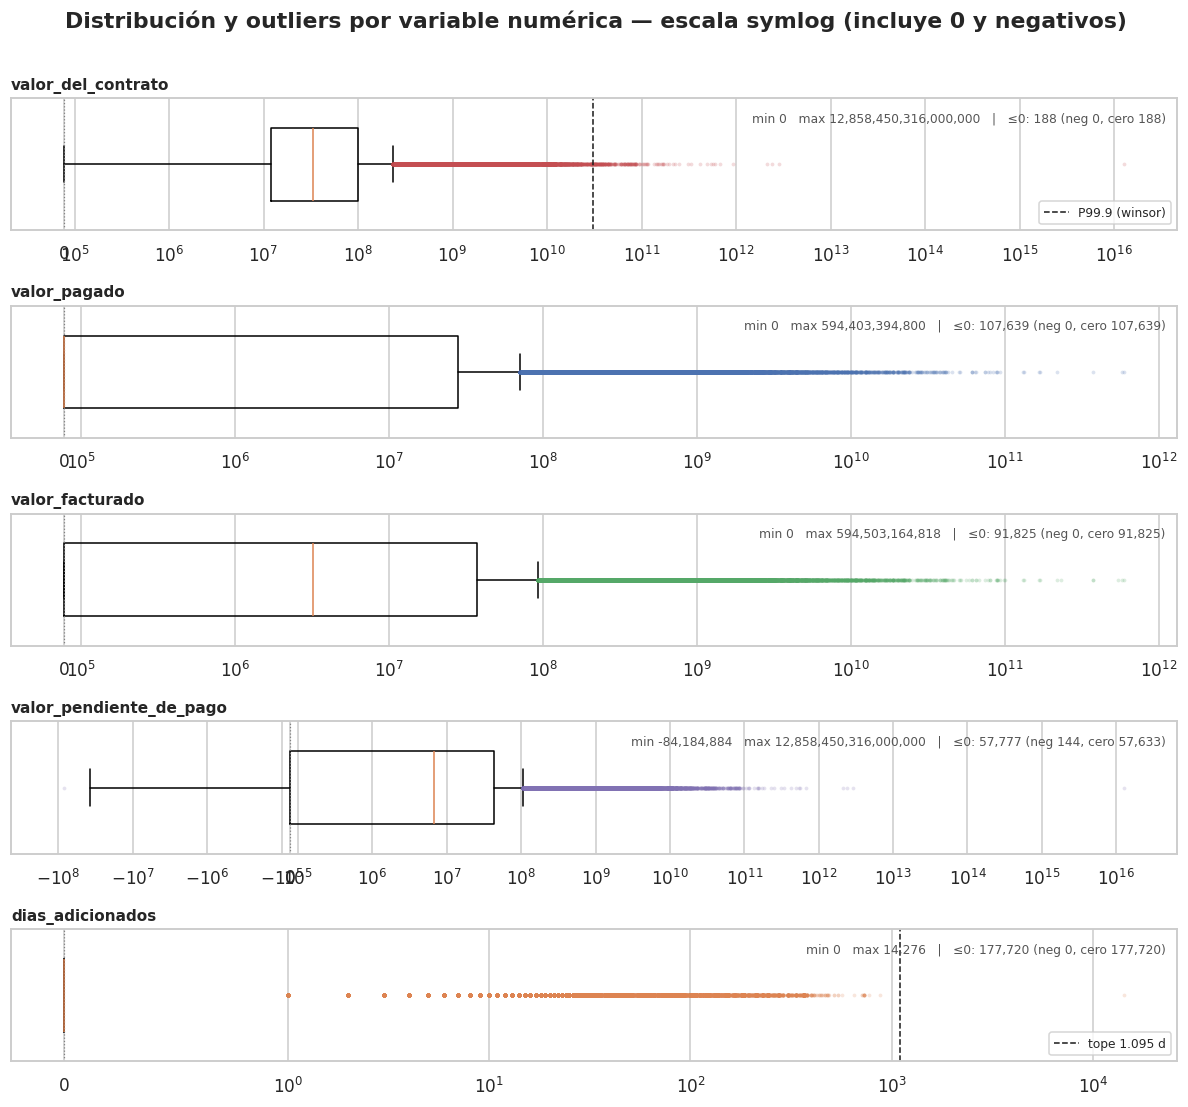

In [19]:
# Un boxplot POR variable numérica (escalas distintas) con escala symlog:
# symlog muestra el bulk, los outliers positivos extremos Y los valores <= 0 / negativos.
num_cols = ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago', 'dias_adicionados']
umbrales = {'valor_del_contrato': (df['valor_del_contrato'].quantile(0.999), 'P99.9 (winsor)'),
            'dias_adicionados': (365*3, 'tope 1.095 d')}
colores = ['#C44E52', '#4C72B0', '#55A868', '#8172B3', '#DD8452']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(11, 2.0*len(num_cols)))
for ax, col, color in zip(axes, num_cols, colores):
    x = df[col].values
    ax.boxplot(x, vert=False, widths=0.55, showfliers=True,
               flierprops=dict(marker='o', markersize=2.5, alpha=0.20, markerfacecolor=color, markeredgecolor='none'))
    ax.set_xscale('symlog', linthresh=(1 if col == 'dias_adicionados' else 1e6))
    ax.axvline(0, color='gray', lw=0.8, ls=':')                      # marca el cero (frontera de negativos)
    if col in umbrales:
        thr, etiqueta = umbrales[col]
        ax.axvline(thr, color='k', lw=1, ls='--', label=etiqueta); ax.legend(loc='lower right', fontsize=8)
    n_neg = int((x < 0).sum()); n_cero = int((x == 0).sum())
    ax.set_yticks([]); ax.set_title(col, fontsize=10, loc='left', fontweight='bold')
    ax.annotate(f'min {x.min():,.0f}   max {x.max():,.0f}   |   ≤0: {n_neg + n_cero:,} (neg {n_neg:,}, cero {n_cero:,})',
                xy=(0.99, 0.82), xycoords='axes fraction', ha='right', fontsize=8, color='#555')
fig.suptitle('Distribución y outliers por variable numérica — escala symlog (incluye 0 y negativos)',
             fontweight='bold', y=1.005)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_outliers_boxplot.png', bbox_inches='tight'); plt.show()


La figura pone cada variable numérica en su propia escala *symlog*, que deja ver a la vez el grueso de los datos,
los extremos (`valor_del_contrato` hasta ~1,3e16 COP; `dias_adicionados` hasta ~14.276 días) y los valores **≤ 0**
(la línea gris punteada marca el cero). Las líneas negras son los umbrales de tratamiento que aplicamos en `02`: la
winsorización del valor en el P99.9 y el tope de 1.095 días.

### 4.2 Nivel de registro: ¿los campos de un mismo contrato cuadran entre sí?

Aquí el problema no es un valor suelto sino una **violación de integridad**: dos campos del mismo contrato que se
contradicen. Todo esto es *consistencia*.

In [20]:
firma, inicio, fin = df['fecha_de_firma'], df['fecha_de_inicio_del_contrato'], df['fecha_de_fin_del_contrato']
valor = df['valor_del_contrato']
trat_fechas = 'Marcar (fecha_inconsistente); no se calculan duraciones con fechas'
trat_montos = 'Marcar (monto_inconsistente); acotar el ratio de ejecución a [0, 1]'

registrar('registro', 'consistencia', 'fechas', 'firma posterior al fin', (firma > fin).sum(), trat_fechas)
registrar('registro', 'consistencia', 'fechas', 'inicio posterior al fin', (inicio > fin).sum(), trat_fechas)
registrar('registro', 'consistencia', 'fechas', 'firma posterior al inicio', (firma > inicio).sum(), trat_fechas)
registrar('registro', 'consistencia', 'valores', 'facturado mayor que el valor del contrato',
          (df['valor_facturado'] > valor).sum(), trat_montos)
registrar('registro', 'consistencia', 'valores', 'pagado mayor que el valor del contrato',
          (df['valor_pagado'] > valor).sum(), trat_montos)
registrar('registro', 'consistencia', 'valores', 'valor ≠ pagado + pendiente',
          ((valor - df['valor_pagado'] - df['valor_pendiente_de_pago']).abs() > 1).sum(),
          'No usar valor_pendiente_de_pago (es derivado de los otros dos)')

en_ejecucion = df['estado_contrato'] == 'En ejecución'
liquidado = df['liquidaci_n'] == 'Si'
registrar('registro', 'consistencia', 'estado_contrato vs liquidaci_n', '"En ejecución" pero marcado como liquidado',
          (en_ejecucion & liquidado).sum(), 'Se documenta como limitación de la bandera sin_liquidar')
print(f'  = {(liquidado[en_ejecucion]).mean() * 100:.1f}% de los contratos en ejecución')

[registro · consistencia] fechas: firma posterior al fin -> 2,601 (1.32%)
[registro · consistencia] fechas: inicio posterior al fin -> 125 (0.06%)
[registro · consistencia] fechas: firma posterior al inicio -> 13,047 (6.64%)
[registro · consistencia] valores: facturado mayor que el valor del contrato -> 214 (0.11%)
[registro · consistencia] valores: pagado mayor que el valor del contrato -> 177 (0.09%)
[registro · consistencia] valores: valor ≠ pagado + pendiente -> 665 (0.34%)
[registro · consistencia] estado_contrato vs liquidaci_n: "En ejecución" pero marcado como liquidado -> 16,634 (8.47%)
  = 32.3% de los contratos en ejecución


Lo de las fechas es sobre todo **firma posterior al inicio** (contratos que se registran después de arrancar); los
casos imposibles, como terminar antes de firmarse, son pocos. En los montos, la identidad
`valor = pagado + pendiente` se cumple casi siempre, lo que confirma que `valor_pendiente_de_pago` no aporta
información propia.

El hallazgo que más pesa para el análisis es el último: un contrato **en ejecución** no puede estar liquidado, y
aun así cerca de un tercio de ellos dice "Si" en `liquidaci_n`. Es probable que el campo no signifique "ya se
liquidó" (podría indicar, por ejemplo, si el contrato *requiere* liquidación). Seguimos usándolo para la bandera
`sin_liquidar`, pero con esa advertencia.

### 4.3 Nivel de columna: ¿la columna entera es coherente?

Problemas que solo se ven mirando la columna completa: un identificador que se repite (**violación de
singularidad**) o dos etiquetas que nombran lo mismo (**sinónimos**). Para los sinónimos quitamos tildes y
mayúsculas: si dos categorías quedan iguales, eran la misma escrita de dos formas.

In [21]:
import unicodedata

registrar('columna', 'precisión', 'id_contrato', 'identificador repetido (violación de singularidad)',
          df['id_contrato'].duplicated().sum(), 'Verificado: sin acción')

normalizar = lambda s: unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode().lower().strip()
cats = ['sector', 'modalidad_de_contratacion', 'tipo_de_contrato', 'orden', 'destino_gasto', 'estado_contrato']
pd.DataFrame({'categorías': [df[c].nunique() for c in cats],
              'sin tildes ni mayúsculas': [df[c].map(normalizar).nunique() for c in cats]}, index=cats)

[columna · precisión] id_contrato: identificador repetido (violación de singularidad) -> 0 (0.00%)


,categorías,sin tildes ni mayúsculas
sector,26,26
modalidad_de_contratacion,9,9
tipo_de_contrato,2,2
orden,4,4
destino_gasto,4,4
estado_contrato,9,9


`id_contrato` es un identificador único y ninguna categoría colapsa al normalizar, así que no hay sinónimos por
escritura ni errores de digitación en las categorías. Los únicos sinónimos son de significado: "No aplica" y
"No Definido" dicen lo mismo (que falta el dato), y ya los contamos en 4.1.

### 4.4 Nivel de tabla: ¿hay contratos repetidos?

No basta con buscar filas idénticas: también hay que buscar **duplicados aproximados**, el mismo registro
cargado dos veces con otro identificador. Buscamos contratos con la misma entidad, el mismo proveedor, el mismo
valor, la misma fecha de firma y el mismo objeto. Los clasificamos en
*precisión* porque un duplicado cuenta dos veces el mismo contrato real.

In [22]:
clave = ['nombre_entidad', 'documento_proveedor', 'valor_del_contrato', 'fecha_de_firma', 'objeto_del_contrato']
registrar('tabla', 'precisión', 'fila completa', 'duplicado exacto', df.duplicated().sum(), 'Verificado: sin acción')
registrar('tabla', 'precisión', 'entidad + proveedor + valor + firma + objeto',
          'duplicado aproximado (mismo contrato, otro id)', df.duplicated(subset=clave).sum(),
          'Se conservan: su efecto en las tasas es despreciable')
df[df.duplicated(subset=clave, keep=False)].sort_values(clave)[
    ['id_contrato', 'nombre_entidad', 'valor_del_contrato', 'fecha_de_firma', 'estado_contrato']].head(4)

[tabla · precisión] fila completa: duplicado exacto -> 0 (0.00%)


[tabla · precisión] entidad + proveedor + valor + firma + objeto: duplicado aproximado (mismo contrato, otro id) -> 36 (0.02%)


,id_contrato,nombre_entidad,valor_del_contrato,fecha_de_firma,estado_contrato
116621,CO1.PCCNTR.5979749,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,"300,000,000.00",2024-02-27,terminado
116622,CO1.PCCNTR.5979853,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,"300,000,000.00",2024-02-27,terminado
152649,CO1.PCCNTR.7576401,Alcaldía De Villamaria,"15,000,000.00",2025-02-28,Aprobado
152679,CO1.PCCNTR.7579851,Alcaldía De Villamaria,"15,000,000.00",2025-02-28,Cerrado


Hay unas pocas decenas de duplicados aproximados, a veces con estados distintos (uno "Aprobado" y otro "Cerrado"),
lo que sugiere el mismo contrato registrado dos veces. Frente a casi 200 mil contratos no cambian ninguna tasa, así
que los dejamos documentados.

### 4.5 Múltiples tablas

**No aplica**: trabajamos con una sola tabla, ya consolidada por SECOP II. Si se cruzara con otra fuente (por
ejemplo, SECOP I o datos presupuestales), habría que revisar los problemas propios de este nivel:
representación heterogénea, sinónimos entre tablas y granularidades distintas.

### 4.6 Las dimensiones que se evalúan con criterio

Cinco de las nueve dimensiones no se miden contando filas, sino mirando de dónde vienen los datos y para qué los
queremos:

- **Relevancia.** El dataset trae los atributos que pide el negocio (valor, modalidad, sector, orden, destino),
  pero no otros que ayudarían: el monto de las adiciones en dinero, el motivo de la adición o la fecha de
  liquidación. De sus 36 columnas usamos 22 (inventario 2.6).
- **Procesabilidad.** Alta: viene en parquet, con fechas y montos ya tipados. Las excepciones son la duración y
  los booleanos, que llegan como texto (4.1).
- **Disponibilidad.** SECOP II es una fuente pública de datos abiertos; trabajamos con el extracto entregado para
  el taller. El archivo no se sube al repositorio por su tamaño, y el README explica cómo obtenerlo.
- **Temporalidad.** Es una foto de un momento, sin fecha de corte explícita. Los contratos de 2024–2025 todavía
  están abiertos y su estado va a cambiar; por eso acotamos el periodo en la sección 3 (se registra abajo).
- **Credibilidad.** La fuente es oficial, pero cada entidad reporta sus propios datos. Eso explica los ceros de
  `valor_pagado` y el `liquidaci_n` ambiguo: confiamos en la fuente, no en cada campo por igual.

In [23]:
registrar('tabla', 'temporalidad', 'fecha_de_firma', 'firmados en 2024–2025, muchos aún abiertos',
          (df['fecha_de_firma'].dt.year >= 2024).sum(), 'Analizar firmas hasta 2023 (sección 3)')

[tabla · temporalidad] fecha_de_firma: firmados en 2024–2025, muchos aún abiertos -> 74,747 (38.06%)


### 4.7 Catálogo de calidad

Todos los hallazgos de esta sección, con su nivel, su dimensión y el tratamiento que se aplica en `02_limpieza`.
Los que dicen "se documenta" no se corrigen: quedan como limitaciones del análisis.

In [24]:
catalogo = pd.DataFrame(hallazgos)
with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:,.2f}'.format):
    display(catalogo)

,nivel,dimension,columna,problema,n,pct,tratamiento
0,atributo,completitud,fecha_de_inicio_del_contrato,nulo,2440,1.24,Imputar con fecha_de_firma y marcar la imputación
1,atributo,completitud,sector,"faltante disfrazado (""No Definido"" / ""No aplica"")",24474,12.46,Se conserva como categoría propia (no se imputa)
2,atributo,completitud,orden,"faltante disfrazado (""No Definido"" / ""No aplica"")",9,0.00,Se conserva como categoría propia (no se imputa)
3,atributo,completitud,destino_gasto,"faltante disfrazado (""No Definido"" / ""No aplica"")",911,0.46,Se conserva como categoría propia (no se imputa)
4,atributo,completitud,valor_pagado,"cero que en buena parte es ""no reportado""",107639,54.81,No usar; medir la ejecución con valor_facturado en contratos cerrados
5,atributo,completitud,duraci_n_del_contrato,"""No definido""",9490,4.83,Queda como nulo al convertir a días
6,atributo,conformidad,duraci_n_del_contrato,"unidad sin número (p. ej. ""Dia(s)"")",11329,5.77,Queda como nulo al convertir a días
7,atributo,conformidad,duraci_n_del_contrato,"texto con número y unidad (""245 Dia(s)"")",175572,89.40,Convertir a días (duracion_dias)
8,atributo,conformidad,estado_contrato,"inicial en minúscula (cedido, terminado)",54273,27.64,Estandarizar la inicial a mayúscula
9,atributo,conformidad,sector,"inicial en minúscula (agricultura, defensa, deportes, interior)",39621,20.17,Estandarizar la inicial a mayúscula


## 5. Síntesis del entendimiento inicial

- **Dimensiones:** 196.391 contratos × 36 columnas (2019–2025).
- **Tipos:** mayoría categóricas/texto, 3 fechas, 5 numéricas (4 monetarias + `dias_adicionados`).
- **Top-5 atributos:** `valor_del_contrato`, `sector`, `modalidad_de_contratacion`, `tipo_de_contrato`,
  `dias_adicionados` (elegidos por su relevancia en el análisis; inventario completo de variables en 2.6).
- **Distribuciones clave:** valor muy sesgado (usar log); sector muy heterogéneo (26 categorías); Suministros
  ~54% / Compraventa ~46%; adiciones de plazo concentradas en 0 (~9,5% con adición); predominio de Mínima cuantía.
- **Periodo:** el `% en ejecución` crece con el año (0%→37,5%) y el ciclo se cierra menos en 2025 → el análisis de
  subejecución y no-liquidación se acotará a años con ciclo cerrado (aprox. **2019–2023**), fijando el corte en `02_limpieza`.
- **Calidad:** recorrimos los niveles de calidad (atributo, registro, columna, tabla y múltiples tablas) y
  clasificamos cada hallazgo en su dimensión. Lo que más pesa: **faltantes disfrazados** (`sector` sin sector real
  en ~1 de cada 8 contratos; ceros de `valor_pagado`), **valores imposibles** (valor ≤ 0 o de ~1,3e16; 39 años de
  adición), fechas que no cuadran y un **`liquidaci_n` que contradice al estado** del contrato. Duplicados, casi
  ninguno. Catálogo completo en 4.7.

**Siguiente paso:** `02_limpieza.ipynb` — aplicar los tratamientos y construir las 3 banderas de desviación
(`adicion_plazo`, `subejecucion`, `sin_liquidar`).
